0. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

0. Import Datasets

In [3]:
dayEvents = pd.read_csv('./dataset/cleaned_dayEvents.csv')
goldPrice = pd.read_csv('./dataset/cleaned_GoldPrice.csv')

In [4]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
0,11,PokhranUnknownII Nuclear Tests,1,5,1998,India,Nuclear & WMD,Pokhran,India declared itself a nuclear state,International community,Atal Bihari Vajpayee,Mixed,1998-05-01
1,12,Mumbai Terror Attacks,1,11,2008,India,Terrorism & Violence,Mumbai,Highlighted the threat of international terrorism,Citizens of Mumbai,LashkarUnknowneUnknownTaiba,Negative,2008-11-01
2,18,Operation Blue Star,1,6,1984,India,Military & Conflict,Amritsar,Removal of armed militants from Golden Temple ...,Sikh community,"Indian Government, Sikh militants",Negative,1984-06-01
3,19,Kargil War,1,5,1999,India,Military & Conflict,"Kargil, Ladakh",India regained control of Kargil; heightened p...,Indian Armed Forces,"Indian Government, Pakistani Military",Positive,1999-05-01
4,20,Right to Information Act Enacted,1,6,2005,India,Legal & Legislation,India,Empowered citizens to seek information from pu...,Indian citizens,Government of India,Positive,2005-06-01


In [5]:
goldPrice.head()

,Date,Price(USD),Price(THB)
0,1979-01-01,233.7,4511.3
1,1979-02-01,251.3,4985.7
2,1979-03-01,240.1,4812.9
3,1979-04-01,245.3,4891.0
4,1979-05-01,274.6,5560.8


In [6]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              389 non-null    int64 
 1   Name of Incident                    389 non-null    object
 2   Day                                 389 non-null    int64 
 3   Month                               389 non-null    int64 
 4   Year                                389 non-null    int64 
 5   Country                             389 non-null    object
 6   Type of Event                       389 non-null    object
 7   Place Name                          389 non-null    object
 8   Impact                              389 non-null    object
 9   Affected Population                 389 non-null    object
 10  Important Person/Group Responsible  389 non-null    object
 11  Outcome                             389 non-null    object

In [7]:
# Change Type to Date datatype
dayEvents['Date'] = pd.to_datetime(dayEvents['Date'])
goldPrice['Date'] = pd.to_datetime(goldPrice['Date'])

In [8]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              389 non-null    int64         
 1   Name of Incident                    389 non-null    object        
 2   Day                                 389 non-null    int64         
 3   Month                               389 non-null    int64         
 4   Year                                389 non-null    int64         
 5   Country                             389 non-null    object        
 6   Type of Event                       389 non-null    object        
 7   Place Name                          389 non-null    object        
 8   Impact                              389 non-null    object        
 9   Affected Population                 389 non-null    object        
 10  Important Person/Group Res

New Column - Gold Change %
- Old Price - New Price / New Price จะได้ % เป็น Price อันใหม่ที่เปลี่ยนไปกี่ %

In [9]:
goldPrice["Gold Change %"] = goldPrice["Price(USD)"].pct_change() * 100

Merge Data

In [10]:
df = dayEvents.merge(
    goldPrice,
    on="Date",
    how="left"
).dropna()

In [11]:
df["Gold Change %"].describe()

count    387.000000
mean       0.813648
std        5.287332
min      -17.377049
25%       -2.223720
50%        0.455270
75%        3.475274
max       27.539062
Name: Gold Change %, dtype: float64

In [12]:
df["Gold Change %"].value_counts().head()

Gold Change %
-1.260860     5
 7.091796     5
 0.787278     5
-2.615907     4
 12.906250    4
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 387 entries, 0 to 388
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              387 non-null    int64         
 1   Name of Incident                    387 non-null    object        
 2   Day                                 387 non-null    int64         
 3   Month                               387 non-null    int64         
 4   Year                                387 non-null    int64         
 5   Country                             387 non-null    object        
 6   Type of Event                       387 non-null    object        
 7   Place Name                          387 non-null    object        
 8   Impact                              387 non-null    object        
 9   Affected Population                 387 non-null    object        
 10  Important Person/Group Responsi

Sort Date by Month and Year

In [14]:
df = df.sort_values(['Year','Month'])

In [15]:
df.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date,Price(USD),Price(THB),Gold Change %
193,609,1979 Iranian Revolution,1,2,1979,Iran,Political,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed,1979-02-01,251.3,4985.7,7.531023
76,174,OneUnknownChild Policy Introduced,1,9,1979,China,Political,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed,1979-09-01,397.3,7894.9,26.086957
188,531,Speak Mandarin Campaign Launched,1,9,1979,Singapore,Cultural & Religious,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive,1979-09-01,397.3,7894.9,26.086957
174,499,Juhayman alUnknownOtaybi's Seizure of the Gran...,1,11,1979,Saudi Arabia,Terrorism & Violence,Mecca,A twoUnknownweek siege that challenged the Sau...,"Saudi Arabian citizens, pilgrims",Juhayman alUnknownOtaybi,Negative,1979-11-01,415.7,8260.5,8.821990
96,245,SovietUnknownAfghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01,512.0,10645.2,23.165745


Plot graph

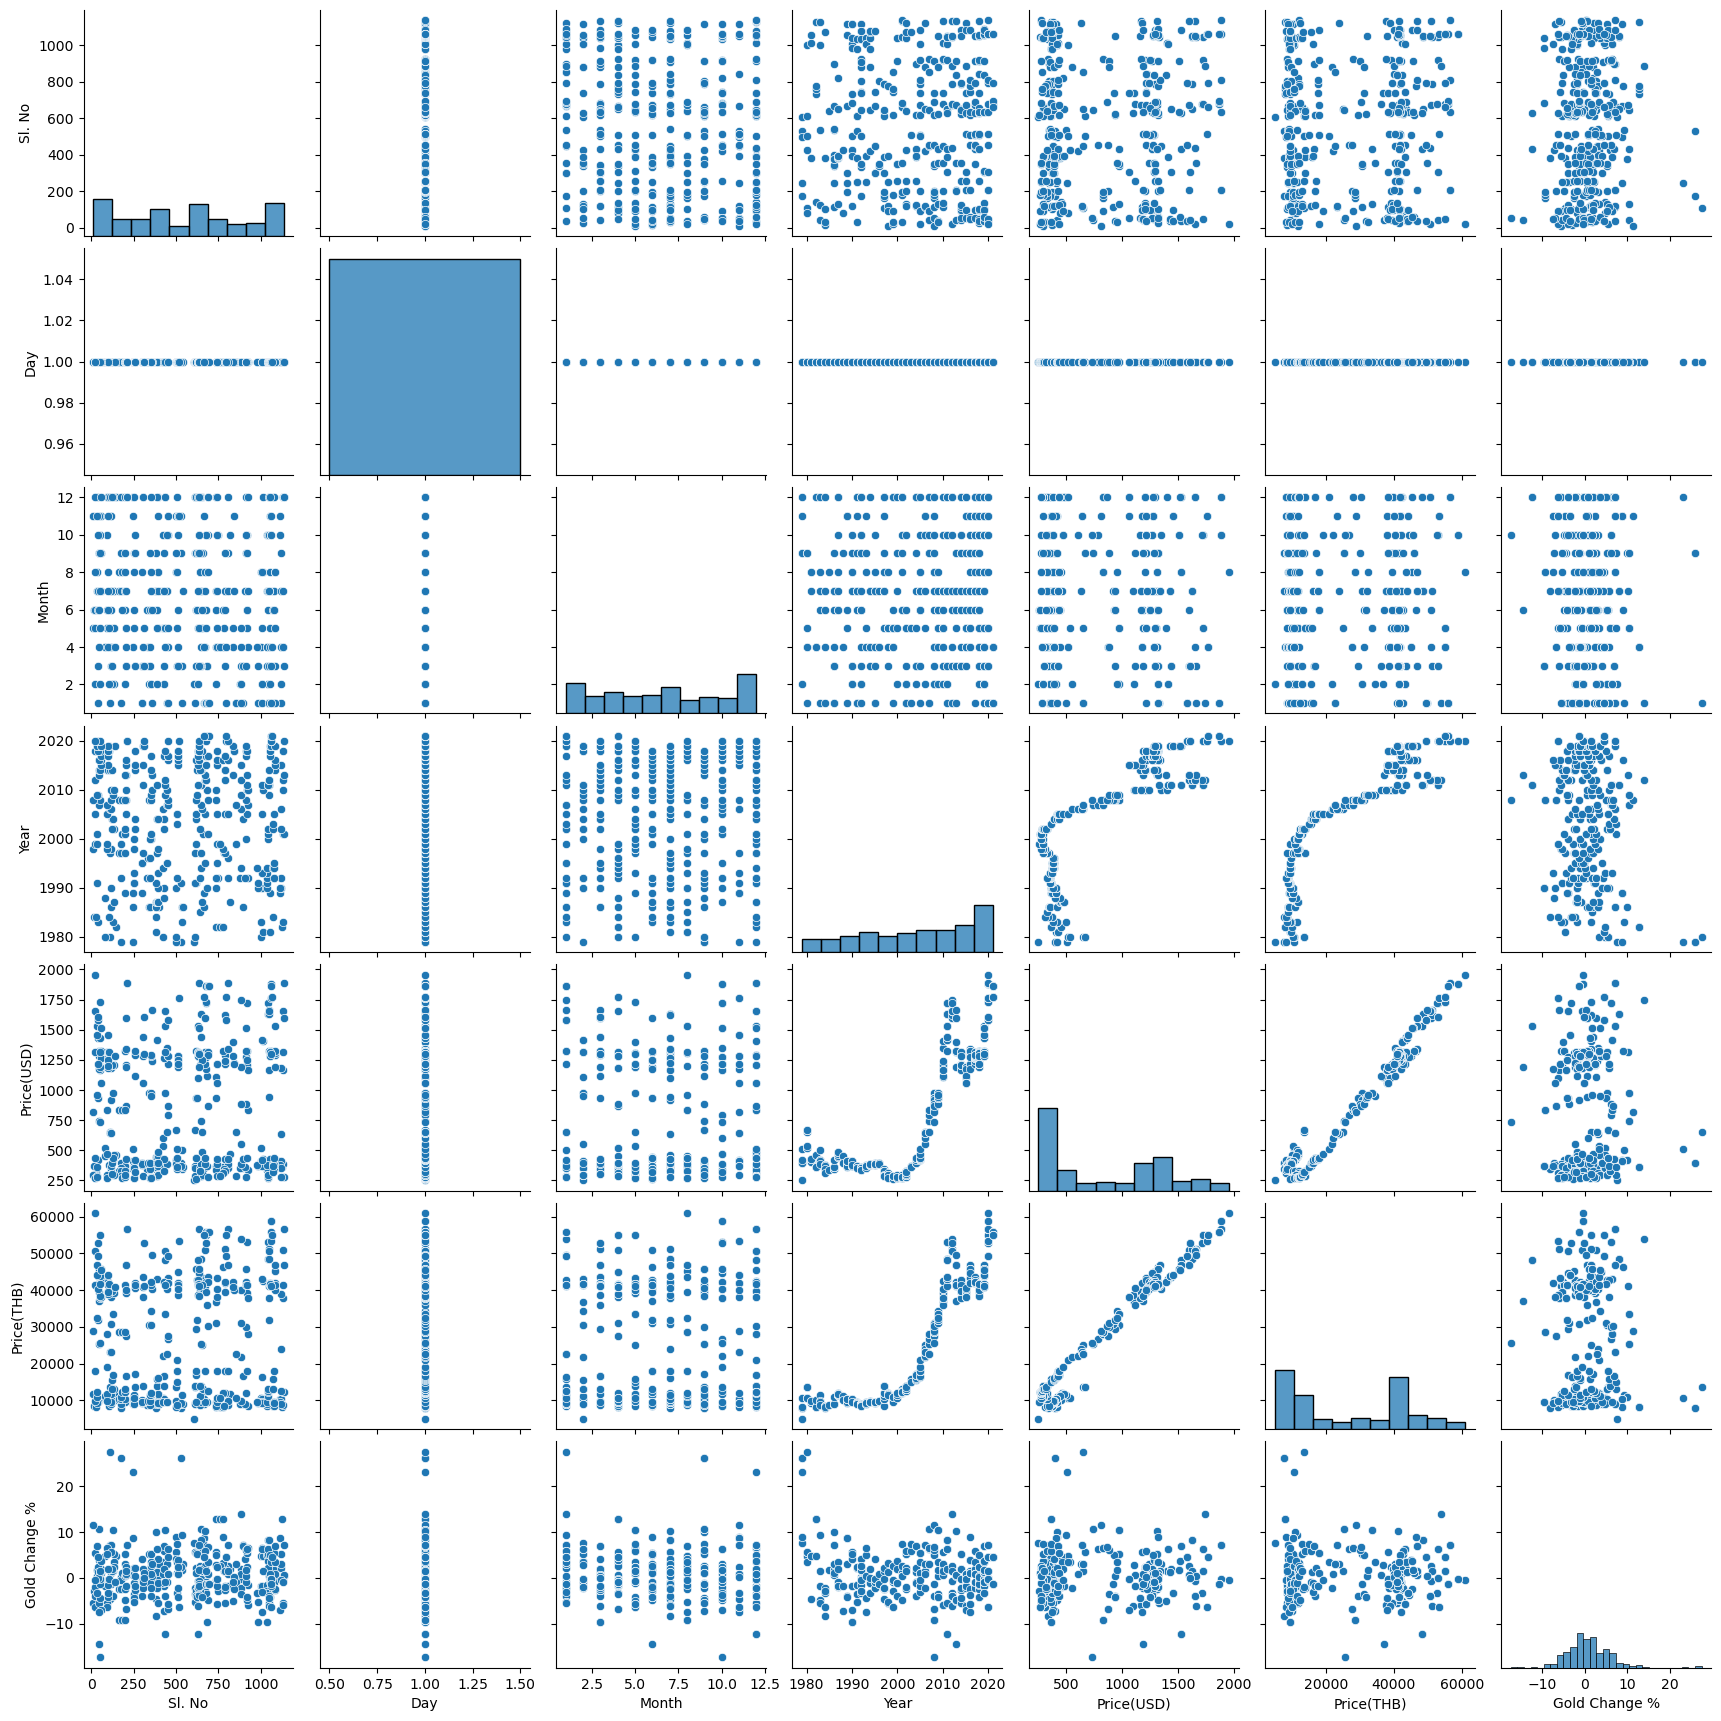

In [16]:
sns.pairplot(df)